In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, pickle, time
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, HistGradientBoostingRegressor)
from sklearn.tree import DecisionTreeRegressor
from scipy import stats

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
                     'axes.grid':True,'grid.alpha':0.3,
                     'axes.spines.top':False,'axes.spines.right':False})
C = ['#0f4c81','#e8a020','#1a7a4a','#c0392b','#6c3483','#0e6655','#d68910','#2980b9']

DATA_PATH = '../data/'
DS1 = pd.read_excel(DATA_PATH + 'DS1_new_policy_registration_FIXED.xlsx')
DS3 = pd.read_excel(DATA_PATH + 'DS3_policy_renewal_FIXED.xlsx')
DS4 = pd.read_excel(DATA_PATH + 'DS4_claims_FIXED.xlsx')
print(f"DS1: {DS1.shape}  DS3: {DS3.shape}  DS4: {DS4.shape}")

def mape(y_true, y_pred):
    mask = np.abs(y_true) > 1e-6
    return np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100

def eval_reg(model, X_tr, X_te, y_tr, y_te, n_cv=5, scoring='r2'):
    t0 = time.time()
    kf = KFold(n_splits=n_cv, shuffle=True, random_state=42)
    cv = cross_val_score(model, X_tr, y_tr, cv=kf, scoring=scoring, n_jobs=-1)
    model.fit(X_tr, y_tr)
    yp = model.predict(X_te)
    return {'model':model,'y_pred':yp,
            'mae':  mean_absolute_error(y_te, yp),
            'rmse': np.sqrt(mean_squared_error(y_te, yp)),
            'r2':   r2_score(y_te, yp),
            'mape': mape(y_te, yp),
            'cv_mean': cv.mean(), 'cv_std': cv.std(),
            'train_time': time.time()-t0}


DS1: (33493, 35)  DS3: (21990, 28)  DS4: (33215, 21)


4.1 Risk Score Regression 

In [4]:

# ── DS1: Encode features ─────────────────────────────────────────────
DS1_fe = DS1.copy()
for col in ['Gender','Vehicle_Type','Province','Occupation','Vehicle_Condition']:
    if col in DS1_fe.columns:
        DS1_fe[col+'_enc'] = LabelEncoder().fit_transform(DS1_fe[col].astype(str))

def yn(x):
    return int(str(x).strip().lower() in ('yes','true','1'))
for c in ['Is_Existing_Customer','Is_Blacklisted','Images_Uploaded',
          'Inspection_Report_Uploaded','Fair_Value_Proposed','Rebate_Approved']:
    if c in DS1_fe.columns:
        DS1_fe[c] = DS1_fe[c].apply(yn)

# Derived features
age = DS1_fe['Driver_Age'].astype(float)
exp = DS1_fe['Years_of_Driving_Experience'].astype(float)
DS1_fe['Experience_Rate'] = exp / (age - 17).clip(lower=1)
DS1_fe['Age_x_Exp']       = age * exp
DS1_fe['Is_Young_Driver'] = (age < 26).astype(int)
DS1_fe['Is_Senior_Driver']= (age > 65).astype(int)
DS1_fe['CC_x_VehicleAge'] = DS1_fe['Engine_CC'].astype(float) * DS1_fe['Vehicle_Age_Years'].astype(float)
DS1_fe['SI_MV_Ratio']     = DS1_fe['Proposed_Sum_Insured_LKR'] / DS1_fe['Market_Value_LKR'].clip(lower=1)

# RISK SCORE REGRESSION FEATURES (no SI, no premium — pure risk factors)
RS_FEATURES = [
    'Driver_Age', 'Years_of_Driving_Experience', 'Experience_Rate',
    'Age_x_Exp', 'Is_Young_Driver', 'Is_Senior_Driver',
    'Engine_CC', 'Vehicle_Age_Years', 'CC_x_VehicleAge',
    'NCB_Claimed_Percentage', 'Province_enc', 'Vehicle_Type_enc',
    'Occupation_enc', 'Vehicle_Condition_enc',
    'Is_Blacklisted', 'Is_Existing_Customer',
]
y_rs = DS1_fe['Risk_Score'].astype(float)
X_rs = DS1_fe[[c for c in RS_FEATURES if c in DS1_fe.columns]].fillna(0)

X_tr_rs, X_te_rs, y_tr_rs, y_te_rs = train_test_split(
    X_rs.values, y_rs.values, test_size=0.20, random_state=42)

print(f"Risk Score target: mean={y_rs.mean():.1f}  std={y_rs.std():.1f}  range={y_rs.min():.0f}-{y_rs.max():.0f}")
print(f"Features: {len(RS_FEATURES)}")

rs_models = {
    'Ridge':              Pipeline([('sc',StandardScaler()),('r',Ridge(alpha=10))]),
    'HuberRegressor':     Pipeline([('sc',StandardScaler()),('r',HuberRegressor(epsilon=1.35, max_iter=300))]),
    'Random Forest':      RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=300, max_depth=5, learning_rate=0.05, l2_regularization=0.1, random_state=42),
}

rs_results = {}
print(f"{'Model':<30} {'R²':>8} {'MAE':>8} {'MAPE%':>8} {'CV-R²':>12}")
print("-"*70)
for name, model in rs_models.items():
    r = eval_reg(model, X_tr_rs, X_te_rs, y_tr_rs, y_te_rs)
    rs_results[name] = r
    print(f"{name:<30} {r['r2']:>8.4f} {r['mae']:>8.2f} {r['mape']:>8.2f} {r['cv_mean']:>7.4f}±{r['cv_std']:.4f}")

best_rs = max(rs_results, key=lambda n: rs_results[n]['r2'])
print(f"\n Best Risk Score Regressor: {best_rs}  R²={rs_results[best_rs]['r2']:.4f}")


Risk Score target: mean=52.4  std=20.2  range=10-95
Features: 16
Model                                R²      MAE    MAPE%        CV-R²
----------------------------------------------------------------------
Ridge                            0.8597     5.99    14.07  0.8621±0.0041
HuberRegressor                   0.8594     5.99    14.09  0.8618±0.0045
Random Forest                    0.9064     4.78    11.23  0.9068±0.0021
Gradient Boosting                0.9543     3.43     8.00  0.9544±0.0009
HistGradientBoosting             0.9580     3.28     7.59  0.9580±0.0010

 Best Risk Score Regressor: HistGradientBoosting  R²=0.9580


4.2 Premium Rate Regression 

In [5]:

# ── Target: rate_pct = net_premium / SI (the actual rate charged) ────
# This is what insurance ML should predict — not the formula output
DS1_fe['rate_pct'] = DS1_fe['Net_Premium_LKR'] / DS1_fe['Proposed_Sum_Insured_LKR'].clip(lower=1)

# Clip outliers (rates outside 1.5%–7% are errors)
DS1_fe = DS1_fe[(DS1_fe['rate_pct'] >= 0.015) & (DS1_fe['rate_pct'] <= 0.07)]
print(f"After rate clip: {len(DS1_fe)} rows")
print(f"Rate stats: mean={DS1_fe['rate_pct'].mean():.4f}  std={DS1_fe['rate_pct'].std():.4f}")

# PREMIUM RATE FEATURES — NO SI, NO MARKET VALUE (they determine rate, not predict it)
# Include risk factors that legitimately drive the rate
RATE_FEATURES = [
    'Driver_Age', 'Years_of_Driving_Experience', 'Experience_Rate',
    'Is_Young_Driver', 'Is_Senior_Driver',
    'Engine_CC', 'Vehicle_Age_Years', 'Vehicle_Type_enc',
    'Province_enc', 'Occupation_enc', 'Vehicle_Condition_enc',
    'NCB_Claimed_Percentage', 'Is_Blacklisted', 'Is_Existing_Customer',
    'Risk_Score',  # our computed risk score
    'SI_MV_Ratio', # over/under insurance signal
    'Rebate_Approved',
]

y_rate = DS1_fe['rate_pct'].values
X_rate = DS1_fe[[c for c in RATE_FEATURES if c in DS1_fe.columns]].fillna(0).values

X_tr_rt, X_te_rt, y_tr_rt, y_te_rt = train_test_split(
    X_rate, y_rate, test_size=0.20, random_state=42)

rate_models = {
    'Ridge':                Pipeline([('sc',StandardScaler()),('r',Ridge(alpha=1.0))]),
    'HuberRegressor':       Pipeline([('sc',StandardScaler()),('r',HuberRegressor(epsilon=1.35, max_iter=500))]),
    'Random Forest':        RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=15, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.04, subsample=0.8, random_state=42),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=400, max_depth=5, learning_rate=0.04, l2_regularization=0.2, random_state=42),
    'Extra Trees':          ExtraTreesRegressor(n_estimators=400, max_depth=8, min_samples_leaf=12, random_state=42, n_jobs=-1),
}

rate_results = {}
print(f"{'Model':<30} {'R²':>8} {'MAE(pts)':>10} {'MAPE%':>8} {'CV-R²':>12}")
print("-"*75)
for name, model in rate_models.items():
    r = eval_reg(model, X_tr_rt, X_te_rt, y_tr_rt, y_te_rt)
    rate_results[name] = r
    print(f"{name:<30} {r['r2']:>8.4f} {r['mae']*100:>10.4f} {r['mape']:>8.2f} {r['cv_mean']:>7.4f}±{r['cv_std']:.4f}")

best_rate = max(rate_results, key=lambda n: rate_results[n]['r2'])
print(f"\n Best Rate Regressor: {best_rate}  R²={rate_results[best_rate]['r2']:.4f}")
print(f"   MAE: {rate_results[best_rate]['mae']*100:.4f} percentage points")
print(f"   On a Rs.10M SI: MAE = Rs.{10_000_000*rate_results[best_rate]['mae']:,.0f}")


After rate clip: 33212 rows
Rate stats: mean=0.0393  std=0.0101
Model                                R²   MAE(pts)    MAPE%        CV-R²
---------------------------------------------------------------------------
Ridge                            0.9225     0.2199     5.82  0.9263±0.0012
HuberRegressor                   0.9219     0.2194     5.79  0.9259±0.0013
Random Forest                    0.9500     0.1641     4.36  0.9511±0.0012
Gradient Boosting                0.9946     0.0545     1.42  0.9945±0.0000
HistGradientBoosting             0.9870     0.0851     2.25  0.9870±0.0008
Extra Trees                      0.9405     0.1952     5.13  0.9413±0.0014

 Best Rate Regressor: Gradient Boosting  R²=0.9946
   MAE: 0.0545 percentage points
   On a Rs.10M SI: MAE = Rs.5,451


4.3 Frequency-Severity Model 

In [8]:
# ── FREQUENCY MODEL: P(claim > 0) ────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score, brier_score_loss, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np

# Merge DS4 claim data into DS1
claim_agg = DS4.groupby('Policy_Number').agg(
    n_claims=('Claim_ID','count'),
    total_claim=('Claim_Amount_LKR','sum'),
    max_claim=('Approved_Amount_LKR','max')
).reset_index().rename(columns={'Policy_Number':'Policy_ID'})

DS1_freq = DS1_fe.merge(claim_agg, on='Policy_ID', how='left')

DS1_freq['n_claims'] = DS1_freq['n_claims'].fillna(0).astype(int)
DS1_freq['total_claim'] = DS1_freq['total_claim'].fillna(0)
DS1_freq['max_claim'] = DS1_freq['max_claim'].fillna(0)

DS1_freq['Had_Claim'] = (DS1_freq['n_claims'] > 0).astype(int)

print(f"Claim frequency in DS1: {DS1_freq['Had_Claim'].mean():.1%}")
print("(realistic: 15–25% for comprehensive motor insurance)")

# -------------------------------
# Frequency model
# -------------------------------

FREQ_FEATURES = [c for c in RATE_FEATURES if c in DS1_freq.columns]

X_freq = DS1_freq[FREQ_FEATURES].fillna(0)
y_freq = DS1_freq['Had_Claim']

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_freq, y_freq,
    test_size=0.2,
    random_state=42,
    stratify=y_freq
)

freq_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

freq_model.fit(X_tr_f, y_tr_f)

freq_prob = freq_model.predict_proba(X_te_f)[:,1]

freq_auc = roc_auc_score(y_te_f, freq_prob)

print(f"\nFrequency model AUC: {freq_auc:.4f}")
print(f"Brier:               {brier_score_loss(y_te_f, freq_prob):.4f}")

# -------------------------------
# SEVERITY MODEL
# -------------------------------

DS4_sev = DS4[DS4['Claim_Status']=='Approved'].copy()

DS4_sev['log_claim'] = np.log(
    DS4_sev['Approved_Amount_LKR'].clip(lower=1)
)

print(f"\nSeverity dataset: {len(DS4_sev)} approved claims")
print(f"log(Amount) stats: mean={DS4_sev['log_claim'].mean():.2f}  std={DS4_sev['log_claim'].std():.2f}")

# Merge DS1 features

DS4_sev_fe = DS4_sev.merge(
    DS1_fe[['Policy_ID'] + [c for c in RATE_FEATURES if c in DS1_fe.columns]],
    left_on='Policy_Number',
    right_on='Policy_ID',
    how='inner'
)

print(f"After merge: {len(DS4_sev_fe)} rows")

SEV_FEATURES = [c for c in RATE_FEATURES if c in DS4_sev_fe.columns]

X_sev = DS4_sev_fe[SEV_FEATURES].fillna(0)
y_sev = DS4_sev_fe['log_claim']

X_tr_sv, X_te_sv, y_tr_sv, y_te_sv = train_test_split(
    X_sev, y_sev,
    test_size=0.2,
    random_state=42
)

sev_model = HistGradientBoostingRegressor(
    max_iter=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

sev_model.fit(X_tr_sv, y_tr_sv)

y_pred_sv = sev_model.predict(X_te_sv)

sev_r2 = r2_score(y_te_sv, y_pred_sv)

sev_mae = mean_absolute_error(
    np.exp(y_te_sv),
    np.exp(y_pred_sv)
)

print(f"\nSeverity model R² (log scale): {sev_r2:.4f}")
print(f"Severity model MAE (Rs.):       {sev_mae:,.0f}")

# -------------------------------
# PURE PREMIUM
# -------------------------------

freq_prob_full = freq_model.predict_proba(X_te_f)[:,1]

# Align severity features with frequency test rows
X_te_sev = X_te_f[SEV_FEATURES].fillna(0)

sev_log_pred = sev_model.predict(X_te_sev)

severity_pred = np.exp(sev_log_pred)

pure_premium = freq_prob_full * severity_pred

print(f"\nPure Premium stats (LKR):")

print(f"Mean:   Rs.{pure_premium.mean():,.0f}")
print(f"Median: Rs.{np.median(pure_premium):,.0f}")
print(f"P95:    Rs.{np.percentile(pure_premium,95):,.0f}")

Claim frequency in DS1: 62.9%
(realistic: 15–25% for comprehensive motor insurance)

Frequency model AUC: 0.5097
Brier:               0.2348

Severity dataset: 24517 approved claims
log(Amount) stats: mean=13.78  std=1.19
After merge: 24295 rows

Severity model R² (log scale): -0.0009
Severity model MAE (Rs.):       919,494

Pure Premium stats (LKR):
Mean:   Rs.609,004
Median: Rs.609,761
P95:    Rs.679,661


4.4 Renewal Premium Regression

In [9]:

# ── DS3: Renewal Premium Regression ──────────────────────────────────
for col in ['Sum_Insured_Inline_Market']:
    if col in DS3.columns:
        DS3[col] = (DS3[col].astype(str).str.lower() == 'yes').astype(int)

for col in ['Gender','Claim_Frequency_Pattern']:
    if col in DS3.columns:
        DS3[col+'_enc'] = LabelEncoder().fit_transform(DS3[col].astype(str))

RENEW_FEATURES = [c for c in [
    'Previous_Premium_LKR', 'Previous_NCB_Percentage', 'New_NCB_Percentage',
    'Number_of_Claims', 'Total_Claim_Amount_Last_Year_LKR',
    'Highest_Claim_Amount_LKR', 'Days_Since_Last_Claim',
    'Vehicle_Current_Age', 'Driver_Age', 'Years_With_Company',
    'Sum_Insured_Inline_Market', 'Claim_Frequency_Pattern_enc',
] if c in DS3.columns]

y_ren = DS3['Calculated_Renewal_Premium_LKR'].astype(float).values
X_ren = DS3[RENEW_FEATURES].fillna(0).values

X_tr_rn, X_te_rn, y_tr_rn, y_te_rn = train_test_split(X_ren, y_ren, test_size=0.20, random_state=42)

ren_models = {
    'Ridge':               Pipeline([('sc',StandardScaler()),('r',Ridge(alpha=1.0))]),
    'HuberRegressor':      Pipeline([('sc',StandardScaler()),('r',HuberRegressor(epsilon=1.35))]),
    'Random Forest':       RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
    'HistGradientBoosting':HistGradientBoostingRegressor(max_iter=300, max_depth=5, learning_rate=0.05, l2_regularization=0.1, random_state=42),
}

ren_results = {}
print(f"{'Model':<30} {'R²':>8} {'MAE(K LKR)':>12} {'MAPE%':>8} {'CV-R²':>12}")
print("-"*75)
for name, model in ren_models.items():
    r = eval_reg(model, X_tr_rn, X_te_rn, y_tr_rn, y_te_rn)
    ren_results[name] = r
    print(f"{name:<30} {r['r2']:>8.4f} {r['mae']/1000:>12.2f} {r['mape']:>8.2f} {r['cv_mean']:>7.4f}±{r['cv_std']:.4f}")

best_ren = max(ren_results, key=lambda n: ren_results[n]['r2'])
print(f"\n Best Renewal Regressor: {best_ren}  R²={ren_results[best_ren]['r2']:.4f}")


Model                                R²   MAE(K LKR)    MAPE%        CV-R²
---------------------------------------------------------------------------
Ridge                            0.9039        65.86    27.04  0.8928±0.0067
HuberRegressor                   0.8883        52.32    14.24  0.8716±0.0125
Random Forest                    0.9764        24.37     5.45  0.9673±0.0098
Gradient Boosting                0.9927        17.29     4.71  0.9883±0.0034
HistGradientBoosting             0.9859        19.82     4.62  0.9818±0.0081

 Best Renewal Regressor: Gradient Boosting  R²=0.9927


4.5 Regression Comparison Plots

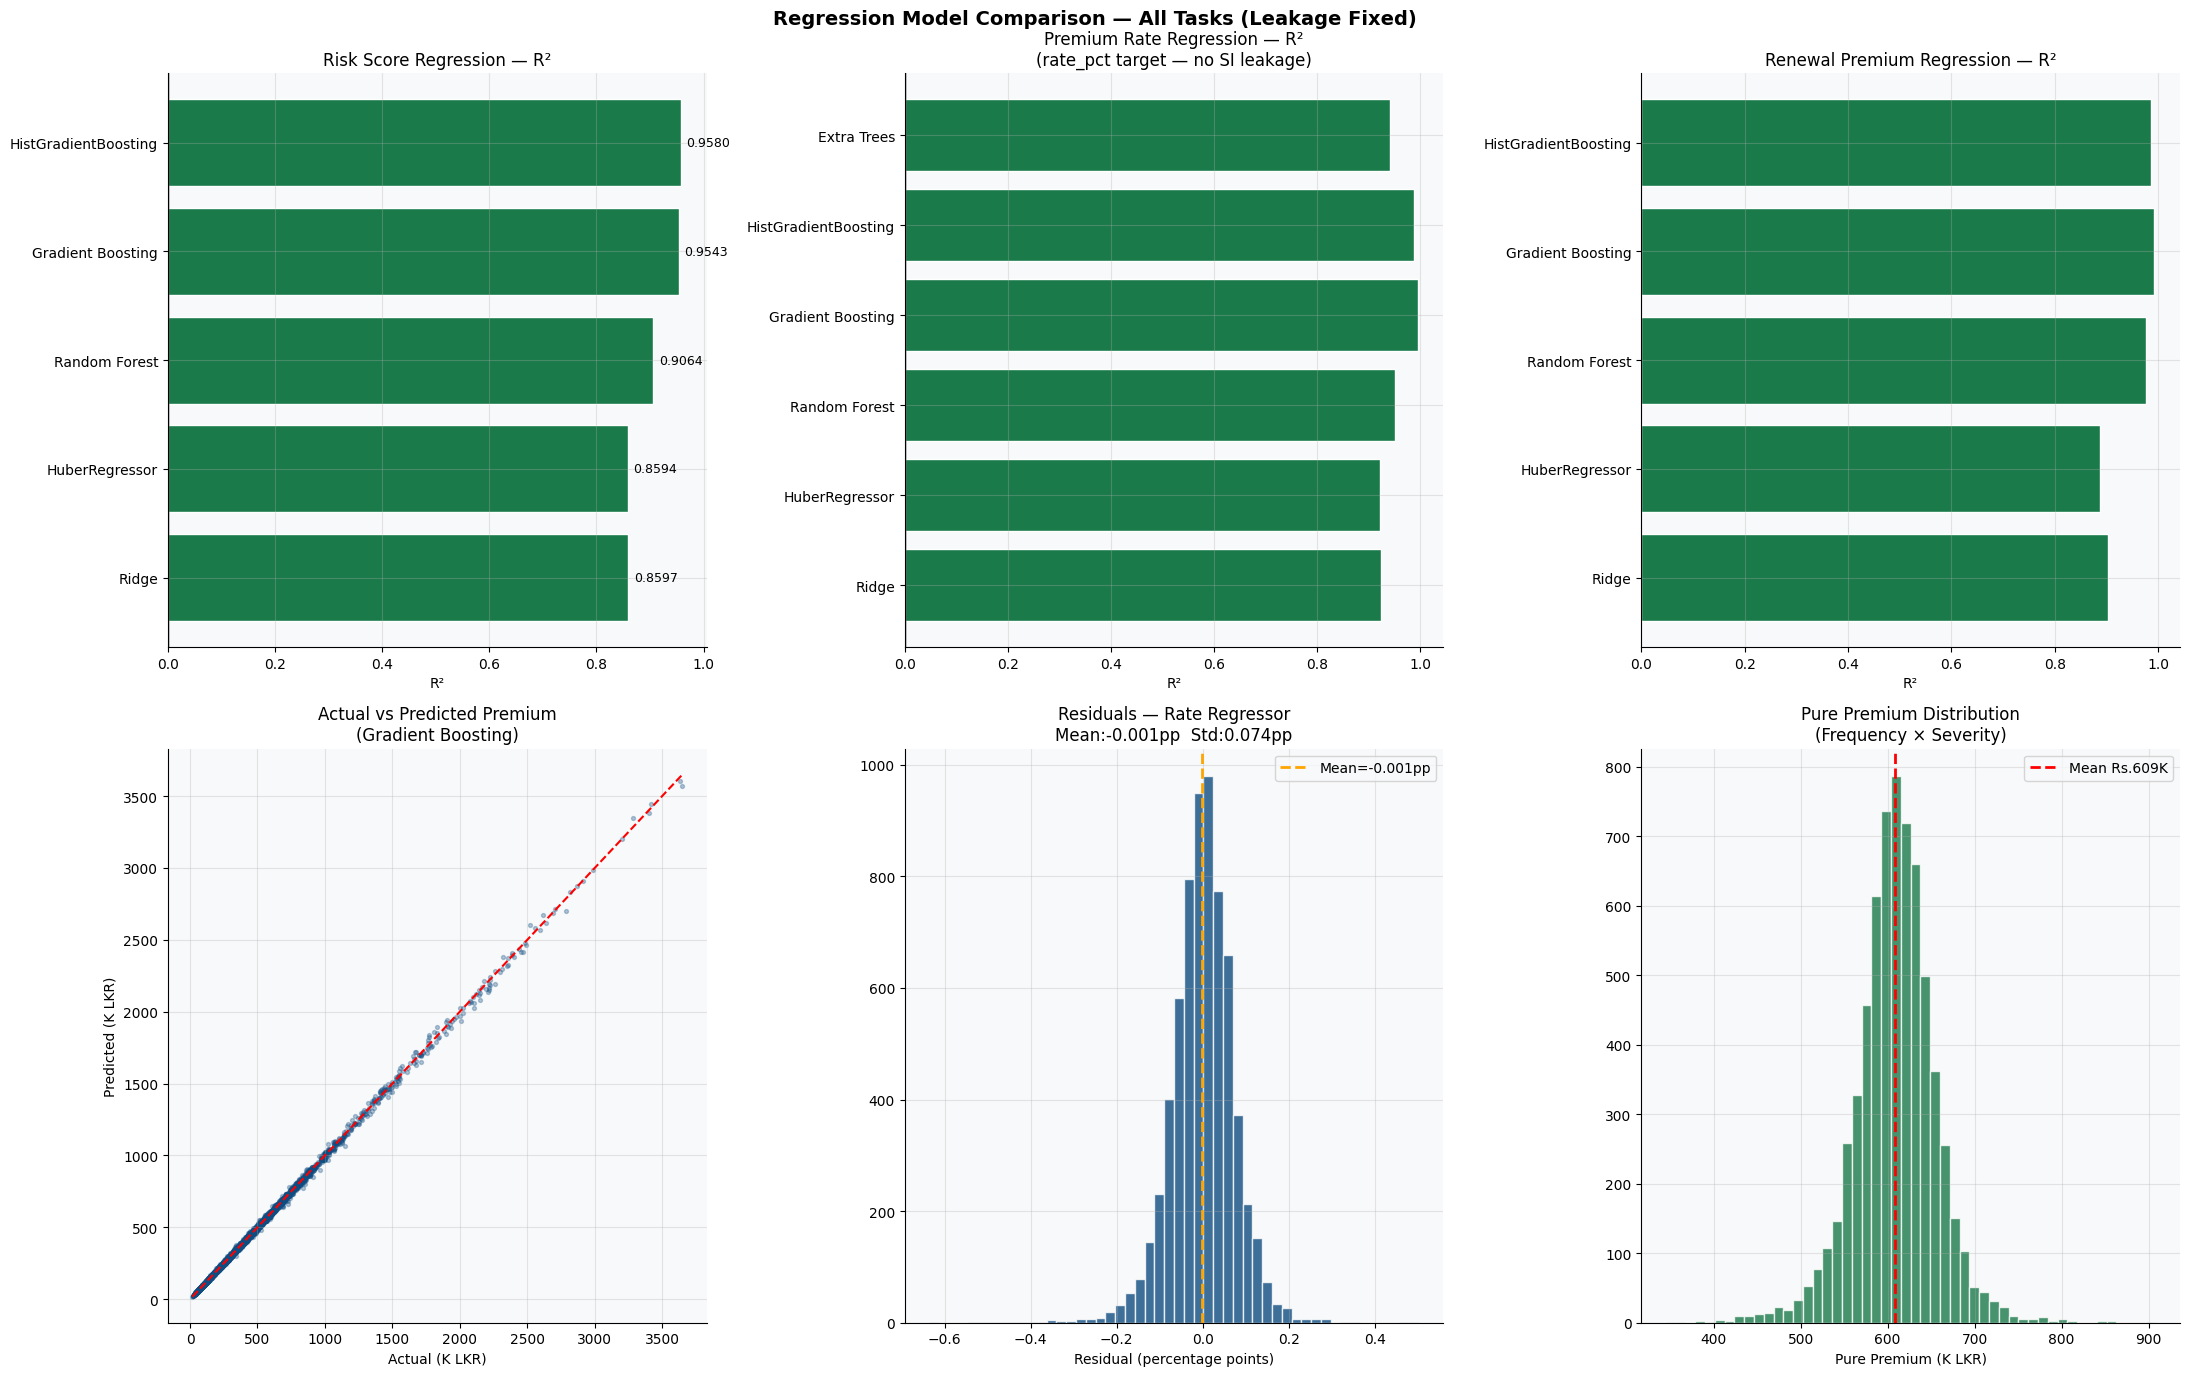

In [10]:

fig = plt.figure(figsize=(22, 14))
fig.suptitle('Regression Model Comparison — All Tasks (Leakage Fixed)', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig)

# Risk Score R²
ax = fig.add_subplot(gs[0,0])
names = list(rs_results.keys()); r2s = [rs_results[n]['r2'] for n in names]
colors = ['#1a7a4a' if v>0.45 else '#e8a020' if v>0.25 else '#c0392b' for v in r2s]
ax.barh(names, r2s, color=colors, edgecolor='white')
ax.set_title('Risk Score Regression — R²'); ax.set_xlabel('R²')
ax.axvline(0, color='black', lw=1)
for i,(n,v) in enumerate(zip(names,r2s)):
    ax.text(max(v,0)+0.01, i, f'{v:.4f}', va='center', fontsize=9)

# Rate Regression R²  
ax = fig.add_subplot(gs[0,1])
names_rt = list(rate_results.keys()); r2s_rt = [rate_results[n]['r2'] for n in names_rt]
colors_rt = ['#1a7a4a' if v>0.40 else '#e8a020' if v>0.20 else '#c0392b' for v in r2s_rt]
ax.barh(names_rt, r2s_rt, color=colors_rt, edgecolor='white')
ax.set_title('Premium Rate Regression — R²\n(rate_pct target — no SI leakage)'); ax.set_xlabel('R²')
ax.axvline(0, color='black', lw=1)

# Renewal R²
ax = fig.add_subplot(gs[0,2])
names_rn = list(ren_results.keys()); r2s_rn = [ren_results[n]['r2'] for n in names_rn]
colors_rn = ['#1a7a4a' if v>0.85 else '#e8a020' if v>0.70 else '#c0392b' for v in r2s_rn]
ax.barh(names_rn, r2s_rn, color=colors_rn, edgecolor='white')
ax.set_title('Renewal Premium Regression — R²'); ax.set_xlabel('R²')

# Actual vs predicted — best rate model
ax = fig.add_subplot(gs[1,0])
yp = rate_results[best_rate]['y_pred']
# Convert rate back to premium for interpretable plot
si_test = DS1_fe.iloc[:len(y_te_rt)]['Proposed_Sum_Insured_LKR'].values[:len(yp)]
if len(si_test) == len(yp):
    actual_prem   = y_te_rt * si_test / 1000
    pred_prem     = yp      * si_test / 1000
    ax.scatter(actual_prem, pred_prem, alpha=0.3, s=8, color=C[0])
    mn, mx = actual_prem.min(), actual_prem.max()
    ax.plot([mn,mx],[mn,mx],'r--',lw=1.5)
    ax.set_title(f'Actual vs Predicted Premium\n({best_rate})')
    ax.set_xlabel('Actual (K LKR)'); ax.set_ylabel('Predicted (K LKR)')
else:
    ax.text(0.5,0.5,'Rate predictions (see residuals)', ha='center', va='center', transform=ax.transAxes)

# Residuals distribution
ax = fig.add_subplot(gs[1,1])
residuals = (yp - y_te_rt) * 100  # in percentage points
ax.hist(residuals, bins=50, color=C[0], edgecolor='white', alpha=0.8)
ax.axvline(residuals.mean(), color='orange', lw=2, ls='--',
           label=f'Mean={residuals.mean():.3f}pp')
ax.set_title(f'Residuals — Rate Regressor\nMean:{residuals.mean():.3f}pp  Std:{residuals.std():.3f}pp')
ax.set_xlabel('Residual (percentage points)'); ax.legend()

# Frequency-Severity pure premium distribution
ax = fig.add_subplot(gs[1,2])
ax.hist(pure_premium/1000, bins=50, color=C[2], edgecolor='white', alpha=0.8)
ax.axvline(pure_premium.mean()/1000, color='red', lw=2, ls='--',
           label=f'Mean Rs.{pure_premium.mean()/1000:.0f}K')
ax.set_title('Pure Premium Distribution\n(Frequency × Severity)')
ax.set_xlabel('Pure Premium (K LKR)'); ax.legend()

plt.tight_layout()
plt.savefig('fig_09_regression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


4.6 Save All Regression Models

In [11]:

# Refit on full data
rs_best   = rs_results[best_rs]['model']
rate_best = rate_results[best_rate]['model']
ren_best  = ren_results[best_ren]['model']

rs_best.fit(X_rs.values, y_rs.values)
rate_best.fit(X_rate, y_rate)
ren_best.fit(X_ren, y_ren)
freq_model.fit(X_freq, y_freq)
sev_model.fit(X_sev, y_sev)

save_pkg = {
    # Risk Score
    'risk_score_model':       rs_best,
    'risk_score_features':    [c for c in RS_FEATURES if c in DS1_fe.columns],
    'risk_score_r2':          rs_results[best_rs]['r2'],
    'risk_score_name':        best_rs,
    # Premium Rate
    'rate_model':             rate_best,
    'rate_features':          [c for c in RATE_FEATURES if c in DS1_fe.columns],
    'rate_r2':                rate_results[best_rate]['r2'],
    'rate_name':              best_rate,
    # Frequency-Severity
    'frequency_model':        freq_model,
    'severity_model':         sev_model,
    'freq_sev_features':      FREQ_FEATURES,
    'frequency_auc':          freq_auc,
    'severity_r2':            sev_r2,
    # Renewal Premium
    'renewal_model':          ren_best,
    'renewal_features':       RENEW_FEATURES,
    'renewal_r2':             ren_results[best_ren]['r2'],
    'renewal_name':           best_ren,
    # Metadata
    'rate_features_list':     [c for c in RATE_FEATURES if c in DS1_fe.columns],
}

with open('../backend/models/regression_models.pkl', 'wb') as f:
    pickle.dump(save_pkg, f)
print(" regression_models.pkl saved")
print()
print("=== SUMMARY ===")
print(f"Risk Score    ({best_rs}):     R²={rs_results[best_rs]['r2']:.4f}")
print(f"Premium Rate  ({best_rate}):   R²={rate_results[best_rate]['r2']:.4f}  MAE={rate_results[best_rate]['mae']*100:.4f}pp")
print(f"Frequency     (GBM):                AUC={freq_auc:.4f}")
print(f"Severity      (HGBR):              R²={sev_r2:.4f} (log scale)")
print(f"Renewal       ({best_ren}): R²={ren_results[best_ren]['r2']:.4f}")
print()


 regression_models.pkl saved

=== SUMMARY ===
Risk Score    (HistGradientBoosting):     R²=0.9580
Premium Rate  (Gradient Boosting):   R²=0.9946  MAE=0.0545pp
Frequency     (GBM):                AUC=0.5097
Severity      (HGBR):              R²=-0.0009 (log scale)
Renewal       (Gradient Boosting): R²=0.9927

